# 1. Data Collection
The manufacturing defects data was extracted from `kaggle`

This dataset contains simulated data related to manufacturing defects observed during `quality control processes`. It includes information such as defect type, detection date, location within the product, severity level, inspection method used, and repair costs. This dataset can be used for analyzing defect patterns, improving quality control processes, and assessing the impact of defects on product quality and production costs.

**Columns:**

`defect_id`: Unique identifier for each defect.

`product_id`: Identifier for the product associated with the defect.

`defect_type`: Type or category of the defect (e.g., cosmetic, functional, structural).

`defect_description`: Description of the defect.
    
`defect_date`: Date when the defect was detected.
    
`defect_location`: Location within the product where the defect was found (e.g., surface, component).

`severity`: Severity level of the defect (e.g., minor, moderate, critical).

`inspection_method`: Method used to detect the defect (e.g., visual inspection, automated testing).

`repair_action`: Action taken to repair or address the defect.
    
`repair_cost`: Cost incurred to repair the defect (in local currency).

**Potential Uses:**

`Quality Control Analysis`: Analyze defect patterns and trends in manufacturing processes.
    
`Process Improvement`: Identify areas for process optimization to reduce defect rates.
                                    
`Cost Analysis`: Evaluate the financial impact of defects on production costs and profitability.
                                    
`Product Quality Assurance`: Enhance product quality assurance strategies based on defect data analysis.

# 2. Data Cleaning


In [2]:
import pandas as pd

df = pd.read_csv("defects_data.csv")
df

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64
...,...,...,...,...,...,...,...,...
995,996,25,Structural,3/1/2024,Component,Minor,Automated Testing,813.14
996,997,23,Functional,3/21/2024,Component,Moderate,Automated Testing,944.07
997,998,17,Structural,1/16/2024,Component,Minor,Automated Testing,401.12
998,999,96,Cosmetic,6/21/2024,Internal,Moderate,Manual Testing,775.63


In [3]:
df.shape # How large is the dataset?

(1000, 8)

In [4]:
df = df.drop_duplicates() # Removal of data that repeats itself
df

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64
...,...,...,...,...,...,...,...,...
995,996,25,Structural,3/1/2024,Component,Minor,Automated Testing,813.14
996,997,23,Functional,3/21/2024,Component,Moderate,Automated Testing,944.07
997,998,17,Structural,1/16/2024,Component,Minor,Automated Testing,401.12
998,999,96,Cosmetic,6/21/2024,Internal,Moderate,Manual Testing,775.63


In [5]:
# Here we remove whitespaces

df["defect_type"] = df["defect_type"].str.strip()
df["defect_location"] = df["defect_location"].str.strip()
df["severity"] = df["severity"].str.strip()
df["inspection_method"] = df["inspection_method"].str.strip()
df

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64
...,...,...,...,...,...,...,...,...
995,996,25,Structural,3/1/2024,Component,Minor,Automated Testing,813.14
996,997,23,Functional,3/21/2024,Component,Moderate,Automated Testing,944.07
997,998,17,Structural,1/16/2024,Component,Minor,Automated Testing,401.12
998,999,96,Cosmetic,6/21/2024,Internal,Moderate,Manual Testing,775.63


# 3. Exploratory Data Analysis (EDA)

The `Kaggle` dataset is fairly clean. Therefore, we move on to `EDA`

EDA Steps:
- Info() and Describe()
- Classify columns
- Univariate Analysis (Numeric, Catergorical)
- Bivariate Analysis (Numeric vs Numeric, Categorical vs Categorical, Numeric vs Categorical)
- Multivariate Analysis
- Outliers
- Insights


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   defect_id          1000 non-null   int64  
 1   product_id         1000 non-null   int64  
 2   defect_type        1000 non-null   object 
 3   defect_date        1000 non-null   object 
 4   defect_location    1000 non-null   object 
 5   severity           1000 non-null   object 
 6   inspection_method  1000 non-null   object 
 7   repair_cost        1000 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 62.6+ KB


There are 8 columns
The first two columns are identity columns
Columns 3-7 are `categorical data (non-numeric)`
The last column is a float data
Most of the columns are classification data.
We do not have any nulls

In [8]:
df.describe()

,defect_id,product_id,repair_cost
count,1000.000000,1000.000000,1000.000000
mean,500.500000,50.837000,507.627150
std,288.819436,29.480935,289.623615
min,1.000000,1.000000,10.220000
25%,250.750000,26.000000,270.902500
50%,500.500000,51.000000,506.430000
75%,750.250000,77.000000,759.065000
max,1000.000000,100.000000,999.640000


In [9]:
classification_data = {'column':['defect_id','product_id','defect_type','defect_date','defect_location','severity','inspection_method','repair_cost'],
                       'classification':['numeric(discrete)','numeric(discrete)', 'categorical(nominal)', 'numerical', 'categorical(nominal)','categorical(ordinal)','categorical(nominal)', 'numeric(continuous)'],
                       'data_type':['int','int','object','object','object','object','object','float']
                       }

classification_df = pd.DataFrame(classification_data)
classification_df

,column,classification,data_type
0,defect_id,numeric(discrete),int
1,product_id,numeric(discrete),int
2,defect_type,categorical(nominal),object
3,defect_date,numerical,object
4,defect_location,categorical(nominal),object
5,severity,categorical(ordinal),object
6,inspection_method,categorical(nominal),object
7,repair_cost,numeric(continuous),float


Most of the columns are categorical data 

## 3.1 Univariate Analysis

In [10]:
df

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64
...,...,...,...,...,...,...,...,...
995,996,25,Structural,3/1/2024,Component,Minor,Automated Testing,813.14
996,997,23,Functional,3/21/2024,Component,Moderate,Automated Testing,944.07
997,998,17,Structural,1/16/2024,Component,Minor,Automated Testing,401.12
998,999,96,Cosmetic,6/21/2024,Internal,Moderate,Manual Testing,775.63


*defect_type*

A **defect** is an **imperfection** that occurs during the production process, resulting in the product to **not meet** required specifications, quality standards, or intended performance.

Defect types Include:

- **Structural**: This defect affects the **physical integrity** of the item. Product is unsaleable.

- **Functional**: The product looks good on the outside but does not function as intended.

- **Cosmetic**: Product works and is structurally sound but it **does not reflect the companies brand on the quality of products it produces**. Often sold at a discount if re-work is costly.
    
`What are the typical defects per industry ?` 

`Which method could be used to deal with defects ?`

For example, **Paper Production**:

- Structural defect: Paper is too moist resulting in CULL Paper. Even the feel of it makes you deduce its quality. It cannot go to the customer.

- Functional defect: Wrong trim measurement at the winder results in Misplaced cores. The paper meets all quality specifications, however the miss core causes storage problems and chuck problems for the customer.

- Cosmetic defect: The paper that is close to the spool has creases, if the operator releases a Jumbo too quickly it results in creases on the 4th set at the winder. Paper is perfect, but requires  redressing before sending it to the customer. This defect compromises the sie of the reel to send to customer. i.e. size to send < 1270.


In [11]:
def defect_type_unique_cnt(df, column = 'defect_type'):
    '''
    Identify and summarise unique defect types in a column and plot distribution.

    Parameters
    ----------
    df : pandas DataFrame
        Manufacturing defects dataset
    column : str, default='defect_type'
        Column to analyse

    Returns
    -------
    dict
        Summary statistics for the column
    '''
    
    unique_type = df[column].unique()
    unique_cnt = df[column].nunique()
    unique_pct = (unique_cnt / len(df)) * 100
    
    print(f'Summary of the column - {column}')
    print(f'Unique types: {unique_type}')
    print(f'Unique count of types: {unique_cnt}')
    print(f'Percentage of unique types: {unique_pct}')
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=column, data=df)
    plt.title(f"Distribution of {column}")
    plt.xticks()
    plt.show()

Summary of the column - defect_type
Unique types: ['Structural' 'Functional' 'Cosmetic']
Unique count of types: 3
Percentage of unique types: 0.3


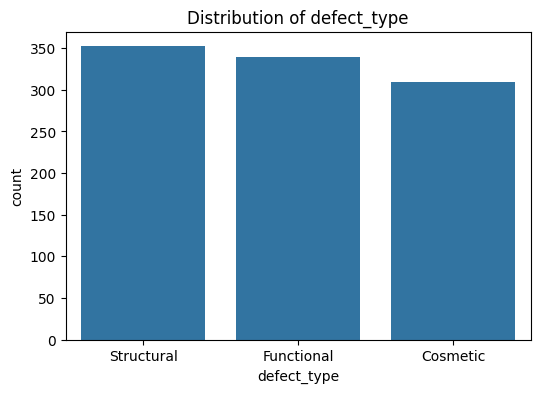

In [12]:
defect_type_unique_cnt(df, 'defect_type')

Based on the plot above, the `structural defect bar is longer than the functional and cosmetic defect bars`, `indicating that structural defects occur more frequently`. This suggests that manufacturers face challenges in maintaining `stable production conditions required to consistently produce quality products`.

*defect_location*

Component defects refer to failures in the individual parts or tools used in production. Internal defects refer to flaws created during the manufacturing process or found within the finished goods.

In [13]:
def defect_location_cnt(df, col='defect_location'):
    unique_defect_location = df[col].unique()
    unique_defect_location_cnt = df[col].nunique()
    unique_defect_location_pct = (unique_defect_location_cnt / len(df)) * 100

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, color = 'orange')
    plt.title(f"Distribution of {col}")
    plt.xticks()
    plt.show()

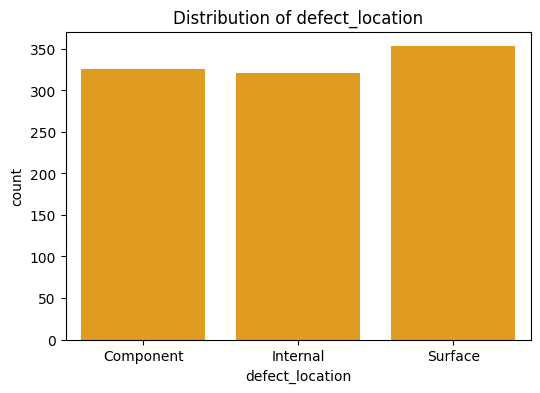

In [14]:
defect_location_cnt(df, 'defect_location')

Based on the plot of defect locations above, it is evident that **surface defects occur more frequently in manufacturing than component and internal defects**. From my experience in **kraft linerboard manufacturing**, the most common defect locations on paper are typically surface and internal.

We tend to observe more surface defects in lower grammage paper, mainly due to the use of waste pulp, which may contain dirt or contaminants. On the sheet, this dirt often appears as blotches, creases, or marks.

In addition, what may be classified as internal defects often relates to property variation detected by the QCS scanner at the dry-end. The QCS may detect variations in key quality parameters such as grammage, burst strength, and SCT, which then require retesting after winding to confirm whether the product still falls within the required specifications.

Overall, the plot shows that component and internal defects are relatively comparable in frequency, while surface defects are clearly the most dominant.

*severity*

**Severity in manufacturing** is the measure of **how serious the impact of a defect, fault, or failure** is **on the product, process, customer, or safety** when it occurs. Often measured using a **severity scale (Minor, Moderate, Critical)**.



In [15]:
def severity_levels(df, column = "severity"):
   ''' 
   Counting severness of defect based on the severity scale terms which are minor, moderate and critical

   Parameters
   ----------
   df : pandas DataFrame
   dataset : Manufacturing dataset
   column : severity column

   Return
   ------
   Plot showing the counts of severity
   '''
   severity_colors = {"Minor" : "Green", "Moderate" : "Orange", "Critical": "Red"}
   plt.figure(figsize = (6,4))
   sns.countplot(x=column, data=df, palette = severity_colors, hue = column)
   plt.title(f"Distribution of {column}")
   plt.xticks()
   plt.show()

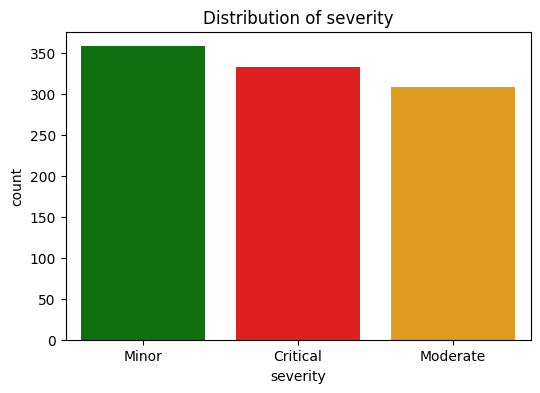

In [16]:
severity_levels(df,"severity")

The plot above shows distribution of severity, minor defects occur more frequent than critical an moderate defects. However, minor defects are **roughly** comparable with critical defects. Critical severity being high may have safety consequences.

*inspection_method*

For every manufacturing there are specific requirements that must be met. **Inspection is systematic evaluation of a process** against specific requirements that must be met. The different inspection method include Visual Inspection, Manual Testing and Automated Testing 

**Visual Inspection** : Is the process of examining a product using the naked eye (or basic optical aids like magnifying glasses) to detect **surface-level defects**. It is often the first line of defense. `Inspection method vs defect_location`.`Example, an operator visually examining reels or webs for blotches,creases and ridges in kraft linerboard manufacturing`.

**Manual Testing** :  Involves a human operator **physically interacting with the product to verify its functionality**. Unlike visual inspection, this is a hands-on process. `Example, an operator using a grinder to cut-off a missplaced core from a finished reel so that there are no stacking problems at the warehouse during stacking`.

**Automated Testing** : Automated testing uses specialized machines, sensors, and software to evaluate a product without human intervention. This is the standard for high-volume, high-precision manufacturing. `Example, QCS scanner picking up that moisture is not within specifications then automatically change the status of the reel or web to CULL. When this reel reaches the strapline, the sensors there detect the status therefore the reel gets sent to the guillotine.`


In [17]:
def inspection(df, column = "inspection_method"):
   ''' 
   Compares varuous inspection methods

   Parameters
   ----------
   df : pandas DataFrame
   dataset : Manufacturing dataset
   column : insepction_method column

   Return
   ------
   Plot showing the counts of methods
   '''
   unique_inspection_method = df[column].unique()
   unique_inspection_method_cnt = df[column].nunique()
   unique_inspection_method_pct = (unique_inspection_method_cnt /len(df))*100
  
   print(f'Summary of the column - {column}')
   print(f'Unique inspection method: {unique_inspection_method}')
   print(f'Count per inspection method: {unique_inspection_method_cnt}')
   print(f'Percentage per inspection: {unique_inspection_method_pct}')
    
   plt.figure(figsize = (6,4))
   sns.countplot(x=column, data=df, color = "Grey")
   plt.title(f"Distribution of {column}")
   plt.xticks()
   plt.show()

Summary of the column - inspection_method
Unique inspection method: ['Visual Inspection' 'Automated Testing' 'Manual Testing']
Count per inspection method: 3
Percentage per inspection: 0.3


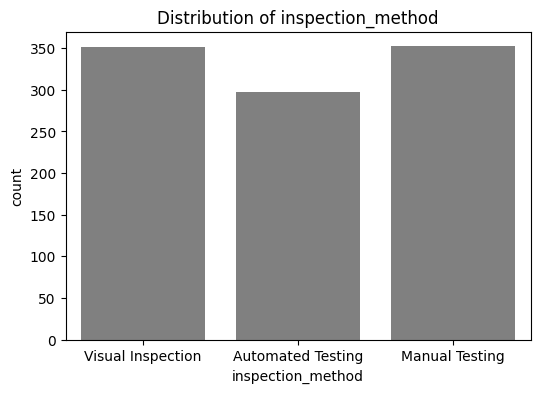

In [18]:
inspection(df, "inspection_method")

The data suggests that Visual Inspection and Manual Testing remain the predominant quality control methods within this manufacturing sector. This trend is likely driven by several factors, including cost-efficiency and existing infrastructure. Many facilities utilize legacy systems and older machinery, making them heavily reliant on manual labor rather than high-cost automation. From a financial perspective, the upfront capital expenditure required for automated systems often outweighs the cost of employing a skilled workforce. Furthermore, in high-pressure production environments, a skilled technician can often perform rapid visual checks and manual adjustments more flexibly than automated systems, which may be prone to technical downtime or glitches.The data suggests that Visual Inspection and Manual Testing remain the predominant quality control methods within this manufacturing sector. This trend is likely driven by several factors, including cost-efficiency and existing infrastructure. Many facilities utilize legacy systems and older machinery, making them heavily reliant on manual labor rather than high-cost automation. From a financial perspective, the upfront capital expenditure required for automated systems often outweighs the cost of employing a skilled workforce. Furthermore, in high-pressure production environments, a skilled technician can often perform rapid visual checks and manual adjustments more flexibly than automated systems, which may be prone to technical downtime or glitches.

*repair_cost*

These are expenses a company incurs to fix defects, breakdowns and ddamaged products. 

We are doing univariate analysis on the Manufacturing datasets. We will **Assume** that the units are USD.

In [19]:
import numpy as np
import seaborn as sns

def repair_costs_measures(df, column = "repair_cost"):
    '''
    
    Identify the most common cost, steadiness of cost, lowest, highest, outlier , and skewness 

    Parameters
    ----------
    df : pandas DataFrame
    dataset : Manufacturing dataset
    column: (float) repair_cost

    Returns
    -------
    Measures of central tendency
    Measures of spread

    '''

    # Measures of central tendency
    mean_repair_cost = df[column].mean() 
    median_repair_cost = df[column].median()
    mode_repair_cost = df[column].mode().iloc[0]

    # Measures of spread                                       
    min_repair_cost = df[column].min()
    max_repair_cost = df[column].max()
    range_repair_cost = max_repair_cost - min_repair_cost
    variance_repair_cost = round(df[column].var(),2)
    std_dev_repair_cost = round(df[column].std(),2)

    q1 = round(df[column].quantile(0.25),2)
    q2 = df[column].quantile(0.5)
    q3 = round(df[column].quantile(0.75),2)
    iqr = round(q3 - q1,2)

    mad = np.median(np.abs(df[column] - np.median(df[column])))  # mean absolute deviation
    cv = (std_dev_repair_cost / mean_repair_cost) if mean_repair_cost != 0 else 0  # coefficient of variation
    
    skewness = round(df[column].skew(), 2)
    
    summary_repair_cost = {
        "Mean": round(float(mean_repair_cost), 2),
        "Median": median_repair_cost,
        "Mode": float(mode_repair_cost),
        "Min": min_repair_cost,
        "Max": max_repair_cost,
        "Range": range_repair_cost,
        "Variance": variance_repair_cost,
        "Standard Deviation": std_dev_repair_cost,
        "Q1": float(q1),
        "Q3": float(q3),
        "IQR": float(iqr),
        "MAD": round(float(mad),2),
        "CV": round(float(cv),2),
        "Skewness": float(skewness)
    }

    
    print(summary_repair_cost)
    sns.boxplot(x=df['repair_cost'], color = "Yellow")
    plt.title('Repair Cost Five-Number Summary')
    plt.xlabel('Repair cost ($)')
    plt.show()
    
   
    

{'Mean': 507.63, 'Median': 506.43, 'Mode': 379.78, 'Min': 10.22, 'Max': 999.64, 'Range': 989.42, 'Variance': 83881.84, 'Standard Deviation': 289.62, 'Q1': 270.9, 'Q3': 759.06, 'IQR': 488.16, 'MAD': 242.64, 'CV': 0.57, 'Skewness': -0.03}


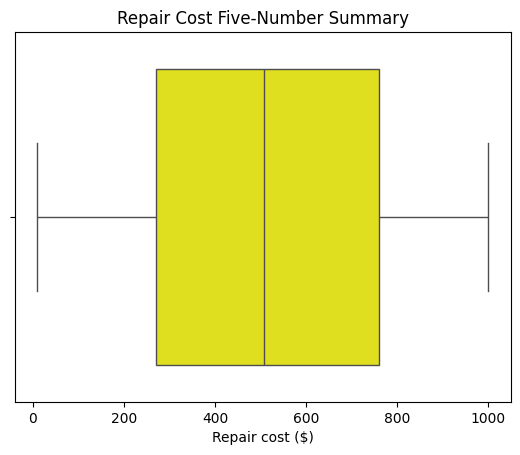

In [20]:
repair_costs_measures(df, "repair_cost")

**Median** is roughly equivalent to the **Mean** which suggests symmetrical distribution. The cost to repair is **mostly stable**. 

**Mode** of `379.78` as the cost that appears the most may be referring to a `preventetive maintanance budget` that is recurring because repairs for defects occur often. 
                                                                                                                                            
**Standard deviation** is low which indicates that the costs are consistent and we can budget with high confidence. 

**CV** is greater than 0.5 which indicates that costs are volatile as such there are expensive breakdowns.

**MAD** is smaller than Standar deviation, which means my repair costs are generally consistent but there are outliers that could be resulting in spikes
                                                                                                                                            
                                                                                                                                               

## 3.2 Bivariate Analysis

*Severity vs Inspection_method*

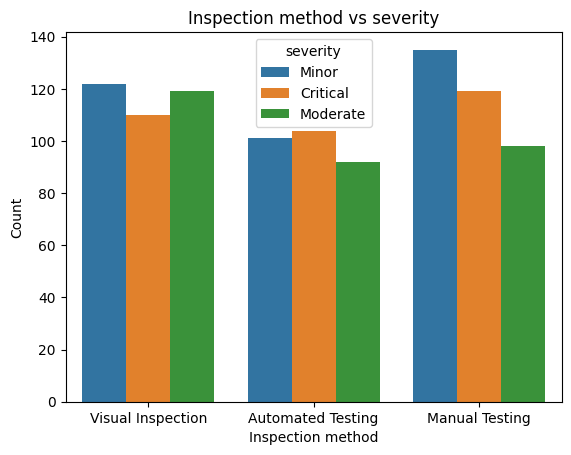

In [21]:
sns.countplot(x='inspection_method', hue = 'severity', data = df)
plt.title('Inspection method vs severity')
plt.xlabel('Inspection method')
plt.ylabel('Count')
plt.show()

Automated testing as an Inspection method is hardly used in manufacturing based on the plot. As seen, the method is used for any severity, the advantage about treating severity the same is that products are fixed and we supply one product to customer. On the other hand, `Is it worth it to fix a minor defect when thaat finished prodduct could be sold at a lower price?`. On the plot, minor defects are tested manual most of the time. Manufacturing relies on human labor for confirmation of its products.

*defect type vs severity*

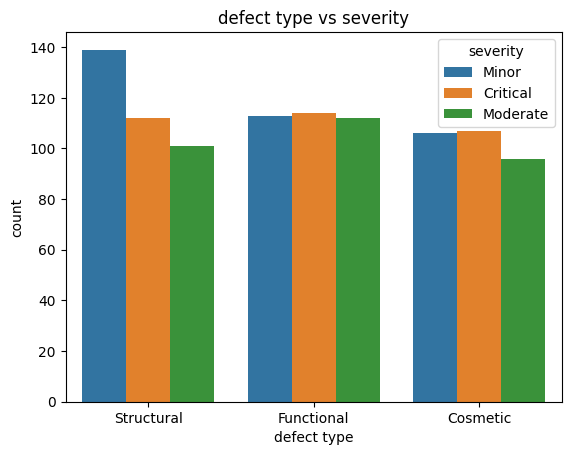

In [22]:
sns.countplot(x='defect_type',hue='severity',data=df)
plt.title('defect type vs severity')
plt.xlabel('defect type')
plt.ylabel('count')
plt.show()

Based on the plot above, the `min and max` are the same across all the inspection methods. 

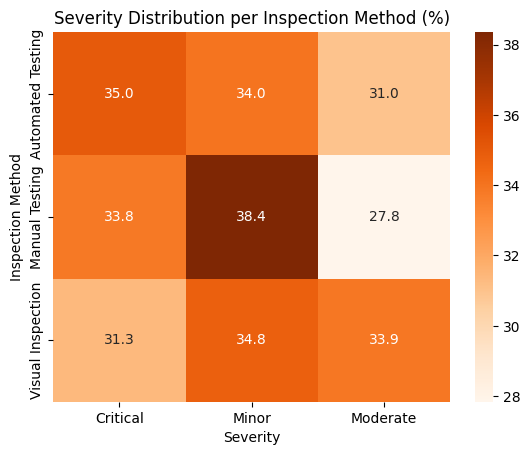

In [23]:
ct = pd.crosstab(df['inspection_method'], df['severity'], normalize='index') * 100

sns.heatmap(ct, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Severity Distribution per Inspection Method (%)")
plt.ylabel("Inspection Method")
plt.xlabel("Severity")
plt.show()


For minor severity defects, Manual testing is the dominant Inspection method with a percentage of 38.4. followed by Visual Inspection and the Automated Testing. Manual testing dominates because manufacturing is reliant on a skillful workforce, workers interact with the product to test for defects. This is a cost friendly method of inspection compared to Automated Testin which require high capital to introduce to a company. 

Critical severity defects, Automated testing is most favorable. Could be due to health and safety implications. Typically, a licensed and skilled operator will operate the specialized machine.

Moderate severity defects, are mostly handled through visual inspection. On the heatmap 33.9 % is visual inspection. Simple to perform and cost effective as there is no need for sophisticated machinery.

*inspection_method vs repair_cost*

The cost to repair a finished products is **dependent** on the inspection method. Inspection is part of the process. In the plot below we will be looking at how costs vary based on an inspection method choosen



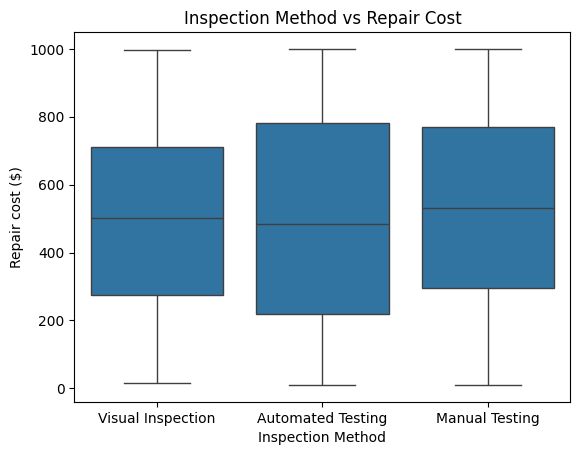

In [24]:
sns.boxplot(x='inspection_method', y='repair_cost', data=df)
plt.title("Inspection Method vs Repair Cost")
plt.xlabel("Inspection Method")
plt.ylabel("Repair cost ($)")
plt.show()

The `data counts` for Visual Inspection and Manual Testing are the `same`, as observed in the previous plot of Inspection Method. However, the repair cost vs inspection method plot above shows noticeable differences across the methods.

The `median repair costs` are approximately `equal` for all three inspection methods. The Visual Inspection box-and-whisker plot appears `slightly compressed`, suggesting that repair costs are more `consistent` for this method. In contrast, Manual Testing shows a `wider spread`, while Automated Testing has the `longest spread`, indicating `greater variability in repair costs`.

**Visual Inspection** `does not require specialised tools`, making it relatively inexpensive. **Manual Testing**, however, often `requires operators to use specialised equipment`, and if such tools are unavailable or costly to obtain, repair costs may increase. In simple terms, Manual Testing includes both tool and labour costs, whereas Visual Inspection mainly involves labour costs only.

Furthermore, **Automated Testing** may involve `expensive machinery, which can be costly to operate and maintain`. These machines are also prone to *breakdowns and malfunctions*, which can further increase repair costs. 

*severity vs repair_cost*

How does the magnitude of a defect influence the repair costs one ends up spending ?

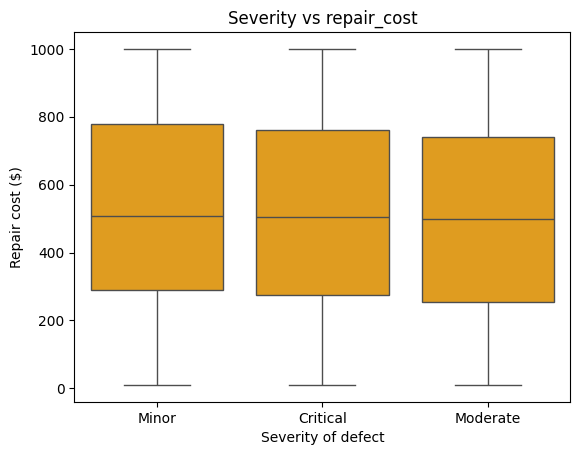

In [25]:
sns.boxplot(x = "severity", y = "repair_cost", color = "orange", data = df)
plt.title("Severity vs repair_cost")
plt.xlabel("Severity of defect")
plt.ylabel("Repair cost ($)")
plt.show()


Baesd on the plot above, There is `no direct relationship between severity and repair_cost`. **both of these factors link through inspection method**. Remember, the magnitude of the defect determines the method you will use an consequently the cost

*defect_type vs defect_location*



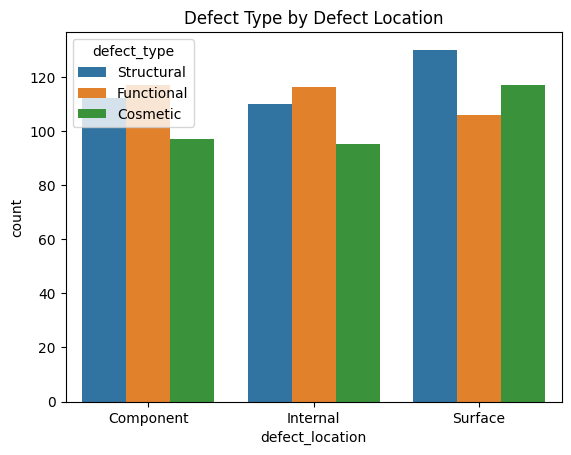

In [26]:
sns.countplot(x="defect_location", hue="defect_type", data=df)
plt.title("Defect Type by Defect Location")
plt.xticks()
plt.show()

Based on the *Defect Type by Defect Location* plot above, on the surface of a product one can easily identify structural defects followed by cosmetic then functional. Furthermore, on the component location of a product, structual and fuctional defects can be identified more readily. Additionally, on the internal location, one can detect functional more easily than cosmetic which require the product to be finished for the defect to be observed


## 3.3 Multivariate Analysis

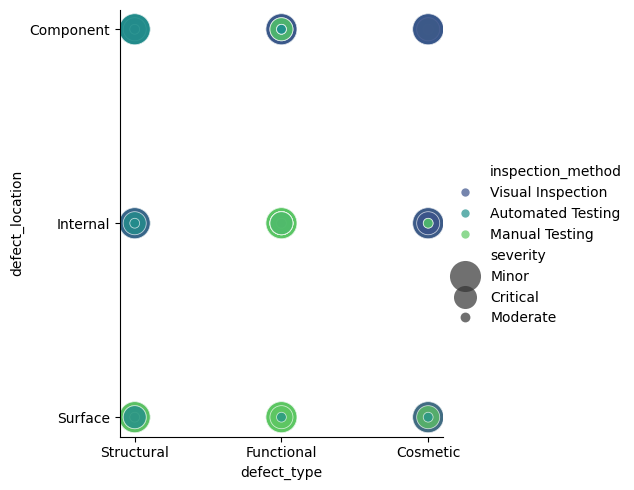

In [27]:
sns.relplot(
    data=df,
    x="defect_type", y="defect_location",
    hue="inspection_method", size= "severity", 
    palette="viridis", alpha=0.7,
    sizes=(50, 500)
)

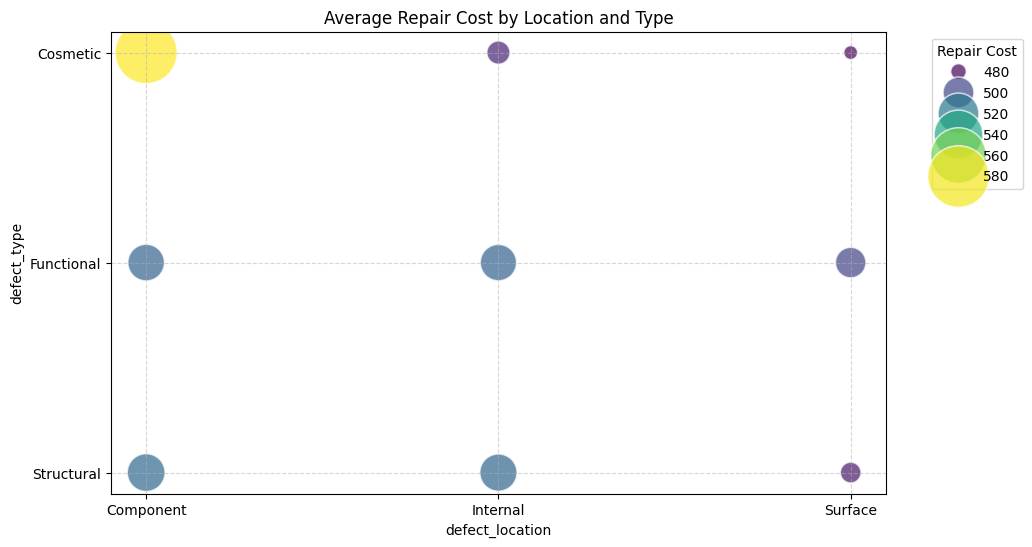

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregating so we have one bubble per intersection
df_grouped = df.groupby(['defect_location', 'defect_type'])['repair_cost'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_grouped,
    x="defect_location",
    y="defect_type",
    size="repair_cost",
    hue="repair_cost",
    sizes=(100, 2000), # Adjusts the min/max bubble size
    palette="viridis",
    alpha=0.7
)

plt.title("Average Repair Cost by Location and Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Repair Cost')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

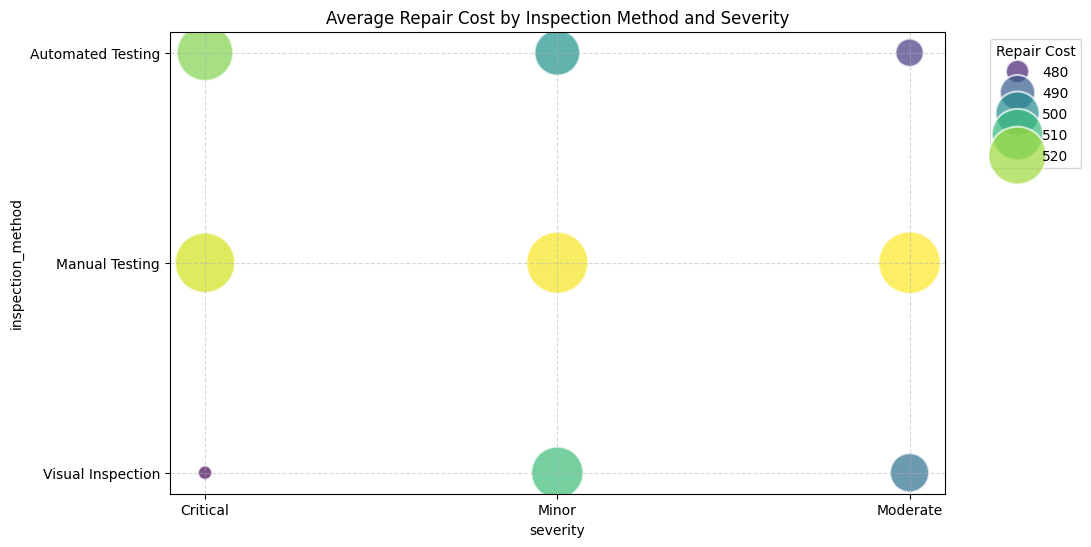

In [29]:
df_grouped = df.groupby(['inspection_method', 'severity'])['repair_cost'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_grouped,
    x="severity",
    y="inspection_method",
    size="repair_cost",
    hue="repair_cost",
    sizes=(100, 2000), # Adjusts the min/max bubble size
    palette="viridis",
    alpha=0.7
)

plt.title("Average Repair Cost by Inspection Method and Severity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Repair Cost')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

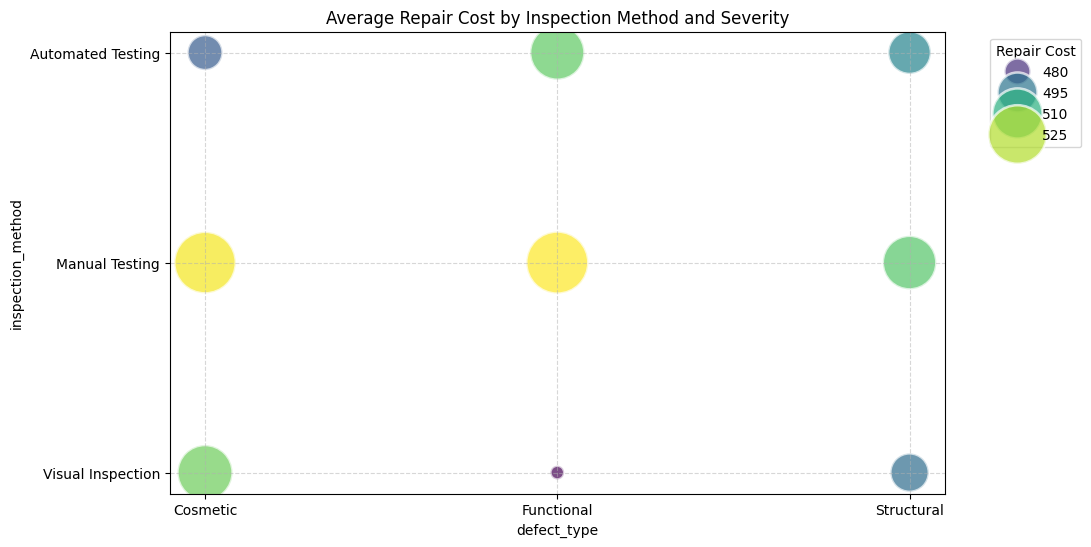

In [30]:
df_grouped = df.groupby(['inspection_method', 'defect_type'])['repair_cost'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_grouped,
    x="defect_type",
    y="inspection_method",
    size="repair_cost",
    hue="repair_cost",
    sizes=(100, 2000), # Adjusts the min/max bubble size
    palette="viridis",
    alpha=0.7
)

plt.title("Average Repair Cost by Inspection Method and Severity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Repair Cost')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Plot 1: 
Plot 2 : Critically severe defects that require visual inspection are cheap averaging less than $480. Cost of Manual testing is constant regardless of the severity level (minor, moderate, critical). The cost of performing visual inspection decreases proportionally with severity from minor to critical. The cost of performing Automated testing is at its highest for critical severity. 
Plot 3:  Functionality of a product is determined during production and it becomes cheap when the worker can visually identify the cause of functionality defect as opposed to identifying defect from a finished product which is where cosmetic defects enter.` Manual testing cost is constant regardless of the defect type`. It is cheap to assesss cosmetic defects than functional and structural using Automated testing.                                                                                                                                                                                                                                                                                                               

## 4 Outliers


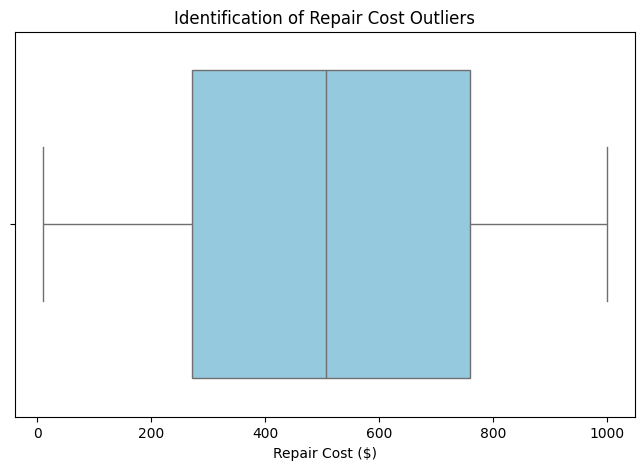

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["repair_cost"], color="skyblue")

plt.title("Identification of Repair Cost Outliers")
plt.xlabel("Repair Cost ($)")
plt.show()

## Control Chart

In [32]:
df['defect_date'] = pd.to_datetime(df['defect_date'])
df_indexed = df.set_index('defect_date')

df_controlchart = df_indexed.groupby([df_indexed.index.to_period('M'), 'defect_type']).size().unstack(fill_value=0).reset_index()

df_controlchart = df_controlchart.rename(columns={'defect_date': 'Month'})

df_controlchart

defect_type,Month,Cosmetic,Functional,Structural
0,2024-01,65,56,70
1,2024-02,47,55,58
2,2024-03,46,67,62
3,2024-04,49,52,55
4,2024-05,57,66,44
5,2024-06,45,43,63


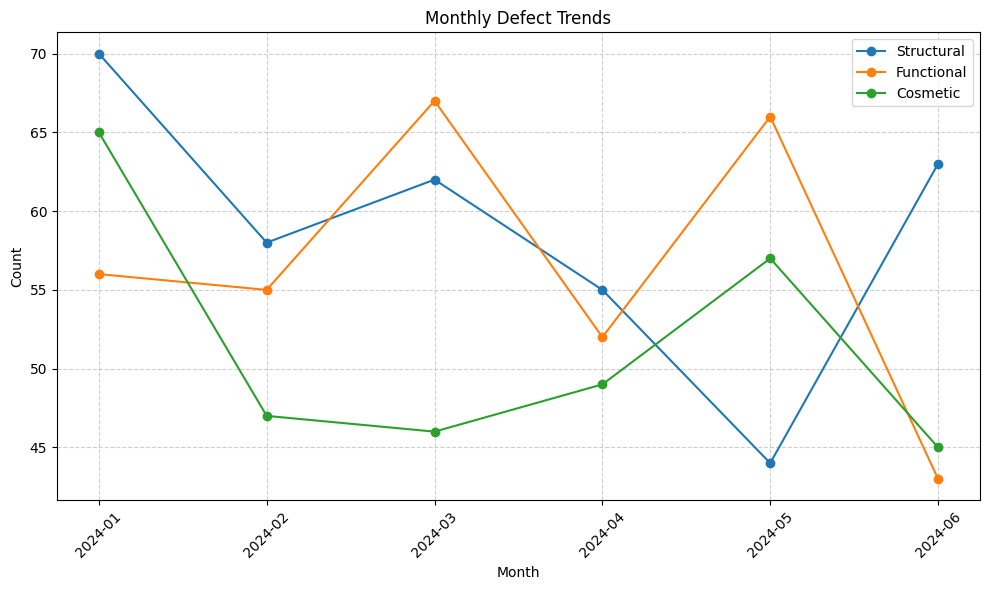

In [33]:
plt.figure(figsize=(10, 6))


plt.plot(df_controlchart['Month'].astype(str), df_controlchart['Structural'], marker='o', label='Structural')
plt.plot(df_controlchart['Month'].astype(str), df_controlchart['Functional'], marker='o', label='Functional')
plt.plot(df_controlchart['Month'].astype(str), df_controlchart['Cosmetic'], marker='o', label='Cosmetic')

plt.title('Monthly Defect Trends')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

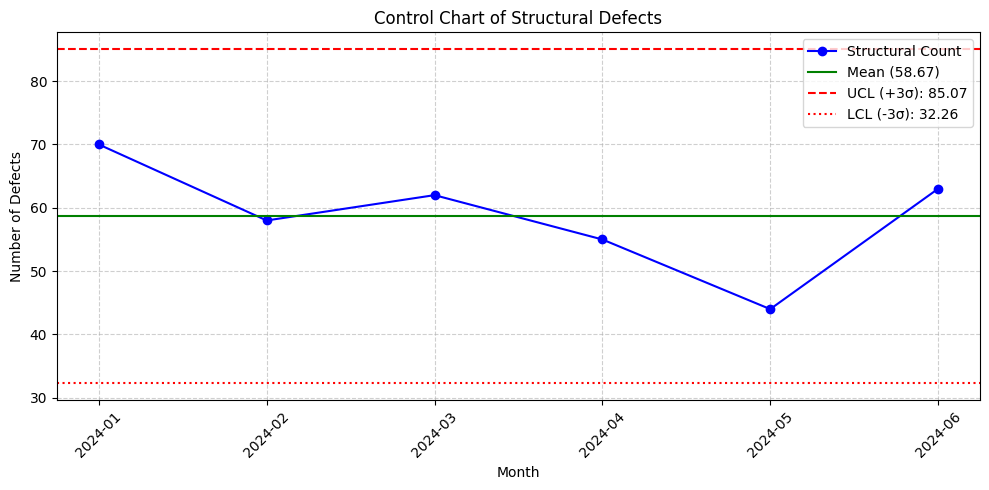

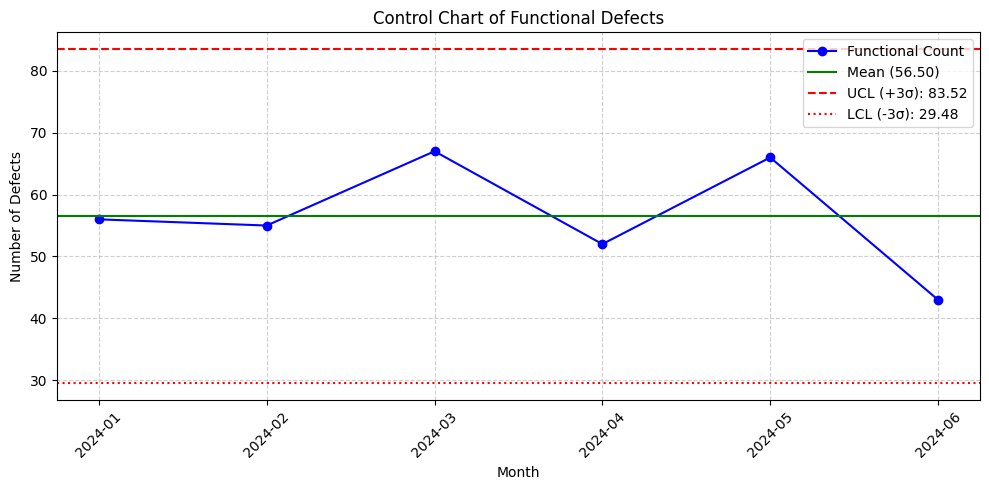

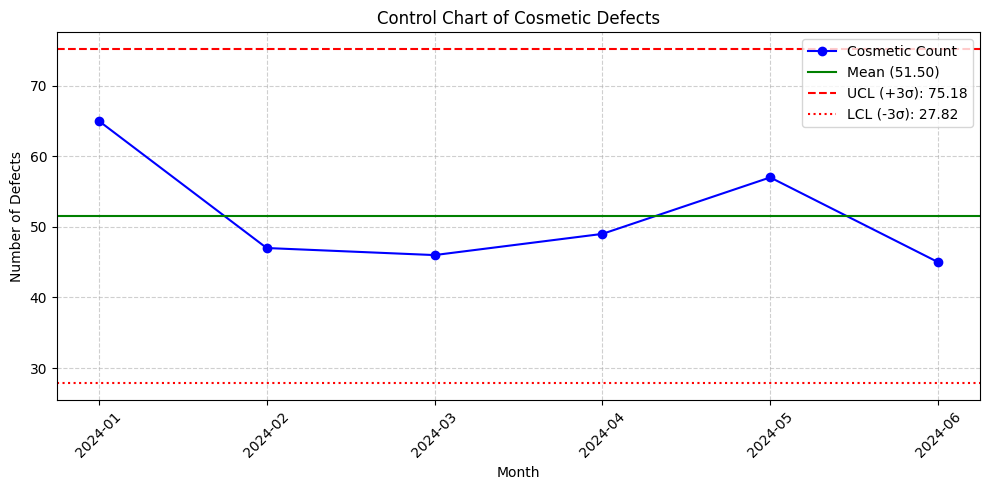

In [34]:

defect_types = ['Structural', 'Functional', 'Cosmetic']

for defect in defect_types:
    plt.figure(figsize=(10, 5))
    
    plt.plot(df_controlchart['Month'].astype(str), df_controlchart[defect], 
             marker='o', color='b', label=f'{defect} Count')
    
    mean_val = df_controlchart[defect].mean()
    std_val = df_controlchart[defect].std()
    
    ucl = mean_val + (3 * std_val)
    lcl = max(0, mean_val - (3 * std_val)) 
    
    plt.axhline(mean_val, color='green', linestyle='-', label=f'Mean ({mean_val:.2f})')
    plt.axhline(ucl, color='red', linestyle='--', label=f'UCL (+3σ): {ucl:.2f}')
    plt.axhline(lcl, color='red', linestyle=':', label=f'LCL (-3σ): {lcl:.2f}')
    
    
    plt.title(f'Control Chart of {defect} Defects')
    plt.xlabel('Month')
    plt.ylabel('Number of Defects')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    plt.show()

## 5 Data Analysis

An `increase in defective products has been observed in the manufacturing process`. This negatively affects the business through increased production costs, waste, and reduced customer satisfaction **[b]**. This analysis aims to investigate `defect trends`, `identify key factors contributing to defects` (such as machine performance, operator practices, and inspection methods), and `recommend actions` to reduce defect rates and improve product quality.

*Defect Trends*

- Univariate
- Bivariate
- Multivariate

*Key Factors...*

- Inspection method vs severity
- Pareto Analysis (80/20 rule)
- Labour and machinery **(Find Articles that support this claim)**

*Recommendations to reduce defects*
Defect reduction is an important aspect of quality improvement in the manufacturing industry, as it directly impacts product quality, customer satisfaction, and operational efficiency [b]. 

[b] found that 23% DMAIC (Define, Measure, Analyze, Improve, Control) is a problem-solving methodology commonly associated with Six Sigma. With the highest percentage, it indicates that DMAIC is widely utilized as an effective method for defect reduction in the manufacturing industry.

Six Sigma: 17% Six Sigma is a data-driven approach aimed at reducing process variation and defects. 

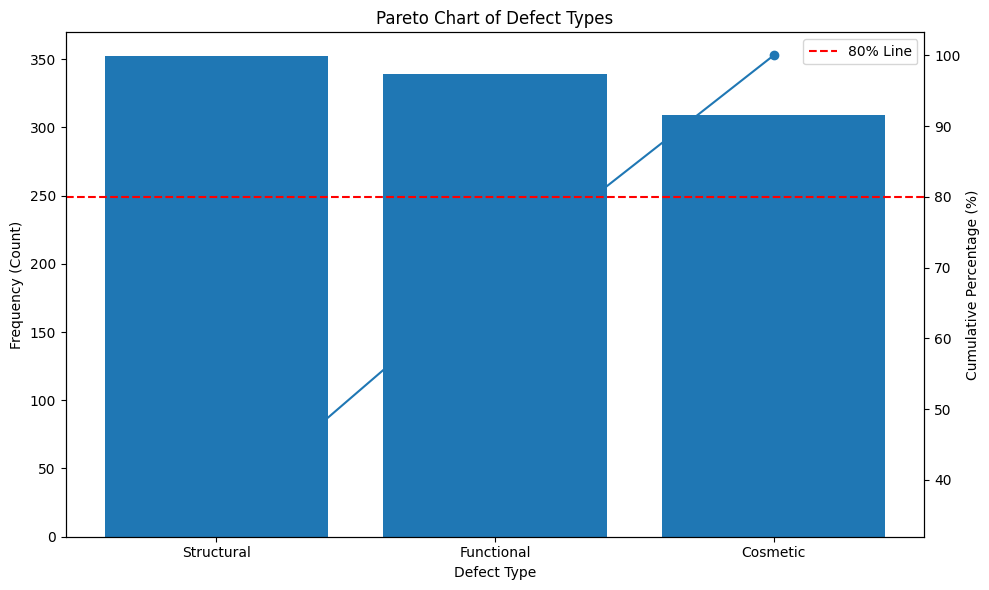

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: replace "defect_type" with your actual column name
defect_counts = df['defect_type'].value_counts()

# Convert to DataFrame
pareto_df = defect_counts.reset_index()
pareto_df.columns = ['Defect Type', 'Count']

# Calculate cumulative percentage
pareto_df['Cumulative %'] = pareto_df['Count'].cumsum() / pareto_df['Count'].sum() * 100

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart (Counts)
ax1.bar(pareto_df['Defect Type'], pareto_df['Count'])
ax1.set_xlabel("Defect Type")
ax1.set_ylabel("Frequency (Count)")
ax1.tick_params(axis='x')

# Line chart (Cumulative %)
ax2 = ax1.twinx()
ax2.plot(pareto_df['Defect Type'], pareto_df['Cumulative %'], marker='o')
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.axhline(80, color='red', linestyle='--', label="80% Line")

# Title
plt.title("Pareto Chart of Defect Types")

# Show legend
ax2.legend(loc="best")

plt.tight_layout()
plt.show()

According to the above plot based on the 80-20 Pareto Principle, Structural defects require immediate attention. then followed by functional and then afterthat can cater to cosmetic. Cosmetic products are saleable they only have minor imperfections that do not reflect the brand of the business but certain customer will still buy. A problem with the structure needs rework an these seem to be a common occurence in manufacturing. Assembling a product coul be great but you fin that it does not work as intended, that is a functionality problem.

## 6. Python Dashboards & GitHub

In [36]:
!pip install panel

In [37]:
!pip install hvplot
